In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [63]:
df = pd.read_csv('titanic_data_updated.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,no,third,male,22.0,1,0,7.2500,S
1,yes,first,female,38.0,1,0,71.2833,C
2,yes,third,female,26.0,0,0,7.9250,S
3,yes,first,female,35.0,1,0,53.1000,S
4,no,third,male,35.0,0,0,8.0500,S


In [65]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [66]:
x = df.drop(['Survived'], axis=1)
y = df['Survived']

x, y

(     Pclass     Sex   Age  SibSp  Parch     Fare Embarked
 0     third    male  22.0      1      0   7.2500        S
 1     first  female  38.0      1      0  71.2833        C
 2     third  female  26.0      0      0   7.9250        S
 3     first  female  35.0      1      0  53.1000        S
 4     third    male  35.0      0      0   8.0500        S
 ..      ...     ...   ...    ...    ...      ...      ...
 886  second    male  27.0      0      0  13.0000        S
 887   first  female  19.0      0      0  30.0000        S
 888   third  female   NaN      1      2  23.4500        S
 889   first    male  26.0      0      0  30.0000        C
 890   third    male  32.0      0      0   7.7500        Q
 
 [891 rows x 7 columns],
 0       no
 1      yes
 2      yes
 3      yes
 4       no
       ... 
 886     no
 887    yes
 888     no
 889    yes
 890     no
 Name: Survived, Length: 891, dtype: object)

In [67]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [68]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,first,male,45.5,0,0,28.5000,S
733,second,male,23.0,0,0,13.0000,S
382,third,male,32.0,0,0,7.9250,S
704,third,male,26.0,1,0,7.8542,S
813,third,female,6.0,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,S
270,first,male,NaN,0,0,31.0000,S
860,third,male,41.0,2,0,14.1083,S
435,first,female,14.0,1,2,120.0000,S


In [69]:
y_train

,Survived
331,no
733,no
382,no
704,no
813,no
...,...
106,yes
270,no
860,no
435,yes


In [70]:
x_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,140
SibSp,0
Parch,0
Fare,0
Embarked,2


In [71]:
x_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,37
SibSp,0
Parch,0
Fare,0
Embarked,0


# missing value handle using Pandas



In [72]:
# mean impute
age_mean = x_train['Age'].mean()

x_train['age_mean_imputer'] = x_train['Age'].fillna(age_mean)

x_test['age_mean_imputer'] = x_test['Age'].fillna(age_mean)

print(x_train)
print(x_test)


     Pclass     Sex   Age  SibSp  Parch      Fare Embarked  age_mean_imputer
331   first    male  45.5      0      0   28.5000        S         45.500000
733  second    male  23.0      0      0   13.0000        S         23.000000
382   third    male  32.0      0      0    7.9250        S         32.000000
704   third    male  26.0      1      0    7.8542        S         26.000000
813   third  female   6.0      4      2   31.2750        S          6.000000
..      ...     ...   ...    ...    ...       ...      ...               ...
106   third  female  21.0      0      0    7.6500        S         21.000000
270   first    male   NaN      0      0   31.0000        S         29.498846
860   third    male  41.0      2      0   14.1083        S         41.000000
435   first  female  14.0      1      2  120.0000        S         14.000000
102   first    male  21.0      0      1   77.2875        S         21.000000

[712 rows x 8 columns]
     Pclass     Sex   Age  SibSp  Parch     Fare Emb

In [73]:
# median impute
age_median = x_train['Age'].median()

x_train['age_median_imputer'] = x_train['Age'].fillna(age_median)

x_test['age_median_imputer'] = x_test['Age'].fillna(age_median)


<Axes: xlabel='Age', ylabel='Density'>

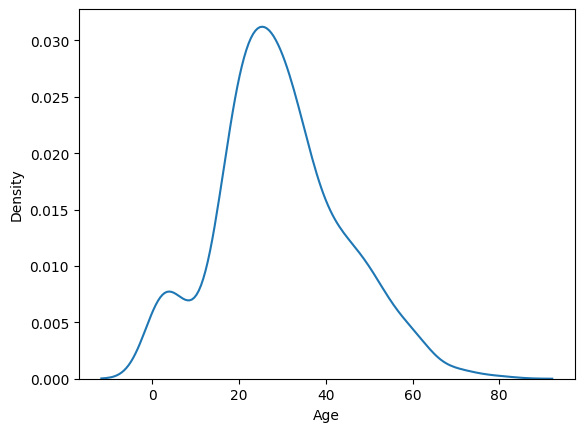

In [74]:
sns.kdeplot(data=x_train, x='Age')

<Axes: xlabel='age_mean_imputer', ylabel='Density'>

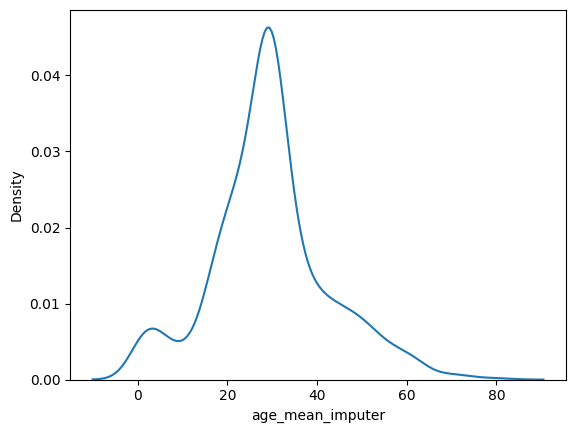

In [75]:
sns.kdeplot(data=x_train, x='age_mean_imputer')

<Axes: xlabel='age_median_imputer', ylabel='Density'>

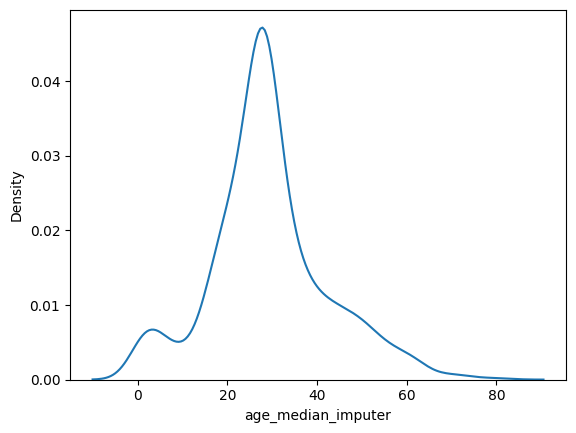

In [76]:
sns.kdeplot(data=x_train, x='age_median_imputer')

# missing value handle using simple imputer


In [77]:
from sklearn.impute import SimpleImputer

age_mean = x_train['Age'].mean()
age_median = x_train['Age'].median()

age_imputor = SimpleImputer(missing_values=np.nan, strategy='mean')

age_imputor.fit(x_train[['Age']])

x_train['Age'] = age_imputor.transform(x_train[['Age']]).ravel()

In [78]:
x_train.isnull().sum()
x_train.drop(['age_mean_imputer', 'age_median_imputer'], axis=1, inplace=True)

In [79]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,first,male,45.500000,0,0,28.5000,S
733,second,male,23.000000,0,0,13.0000,S
382,third,male,32.000000,0,0,7.9250,S
704,third,male,26.000000,1,0,7.8542,S
813,third,female,6.000000,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,S
270,first,male,29.498846,0,0,31.0000,S
860,third,male,41.000000,2,0,14.1083,S
435,first,female,14.000000,1,2,120.0000,S


In [80]:
x_test['Age'] = age_imputor.transform(x_test[['Age']])
x_test.isnull().sum()


,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
age_mean_imputer,0
age_median_imputer,0


In [81]:
x_test.drop(['age_mean_imputer', 'age_median_imputer'], axis=1, inplace=True)

In [82]:
x_test.isnull().sum()


,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [83]:
x_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2


In [84]:
embarked_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

embarked_imputer.fit(x_train[['Embarked']])

x_train['Embarked'] = embarked_imputer.transform(x_train[['Embarked']]).ravel()


In [85]:
x_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [86]:
x_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


# Outlier Detections

## Using Z-Score

In [87]:
mean_of_age = x_train['Age'].mean()
std_of_age = x_train['Age'].std()

x_train["zScore_age"]= (x_train['Age'] - mean_of_age)/ std_of_age

x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,zScore_age
331,first,male,45.500000,0,0,28.5000,S,1.231398e+00
733,second,male,23.000000,0,0,13.0000,S,-5.001304e-01
382,third,male,32.000000,0,0,7.9250,S,1.924808e-01
704,third,male,26.000000,1,0,7.8542,S,-2.692600e-01
813,third,female,6.000000,4,2,31.2750,S,-1.808396e+00
...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,S,-6.540440e-01
270,first,male,29.498846,0,0,31.0000,S,2.734055e-16
860,third,male,41.000000,2,0,14.1083,S,8.850920e-01
435,first,female,14.000000,1,2,120.0000,S,-1.192742e+00


In [88]:
outliers_age = x_train[x_train['zScore_age'] > 3]

print(len(outliers_age))
display(outliers_age)

5


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,zScore_age
116,third,male,70.5,0,0,7.750,Q,3.155317
745,first,male,70.0,1,1,71.000,S,3.116839
630,first,male,80.0,0,0,30.000,S,3.886407
851,third,male,74.0,0,0,7.775,S,3.424666
672,second,male,70.0,0,0,10.500,S,3.116839


In [89]:
mean_of_fare = x_train['Fare'].mean()
std_of_fare = x_train['Fare'].std()

x_train["zScore_fare"]= (x_train['Fare'] - mean_of_fare)/ std_of_fare

x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,zScore_age,zScore_fare
331,first,male,45.500000,0,0,28.5000,S,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,S,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,S,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,S,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,S,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,S,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,S,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,S,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,S,-1.192742e+00,1.682019


In [90]:
outliers_fare = x_train[x_train['zScore_fare'] > 3]

print(len(outliers_fare))
display(outliers_fare)

17


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,zScore_age,zScore_fare
118,first,male,24.000000,0,1,247.5208,C,-4.231736e-01,4.135780
716,first,female,38.000000,0,0,227.5250,C,6.542216e-01,3.751020
377,first,male,27.000000,0,2,211.5000,C,-1.923032e-01,3.442666
742,first,female,21.000000,2,2,262.3750,C,-6.540440e-01,4.421605
380,first,female,42.000000,0,0,227.5250,C,9.620488e-01,3.751020
779,first,female,43.000000,0,1,211.3375,S,1.039006e+00,3.439539
730,first,female,29.000000,0,0,211.3375,S,-3.838960e-02,3.439539
88,first,female,23.000000,3,2,263.0000,S,-5.001304e-01,4.433631
341,first,female,24.000000,3,2,263.0000,S,-4.231736e-01,4.433631
557,first,male,29.498846,0,0,227.5250,C,2.734055e-16,3.751020


## Outliers with IQR

In [91]:
# age

age_q1 = x_train['Age'].quantile(0.25)

age_q3 = x_train['Age'].quantile(0.75)

age_IQR = age_q3 - age_q1

age_minimum = age_q1 - 1.5 * age_IQR

age_maximum = age_q3 + 1.5 * age_IQR


print(age_minimum, age_maximum)

2.5 54.5


In [92]:
age_outlier_IQR = x_train[(x_train['Age'] < age_minimum) | (x_train['Age'] > age_maximum)]

print(len(age_outlier_IQR))
display(age_outlier_IQR)

54


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,zScore_age,zScore_fare
326,third,male,61.00,0,0,6.2375,S,2.424228,-0.507004
483,third,female,63.00,0,0,9.5875,S,2.578141,-0.442543
7,third,male,2.00,3,1,21.0750,S,-2.116223,-0.221500
305,first,male,0.92,1,2,151.5500,S,-2.199336,2.289105
829,first,female,62.00,0,0,80.0000,S,2.501185,0.912337
626,second,male,57.00,0,0,12.3500,Q,2.116401,-0.389387
456,first,male,65.00,0,0,26.5500,S,2.732055,-0.116150
172,third,female,1.00,1,1,11.1333,S,-2.193180,-0.412799
164,third,male,1.00,4,1,39.6875,S,-2.193180,0.136642
381,third,female,1.00,0,2,15.7417,C,-2.193180,-0.324124


In [93]:
# fare

fare_q1 = x_train['Fare'].quantile(0.25)

fare_q3 = x_train['Fare'].quantile(0.75)

fare_IQR = fare_q3 - fare_q1

fare_minimum = fare_q1 - 1.5 * fare_IQR

fare_maximum = fare_q3 + 1.5 * fare_IQR


print(fare_minimum, fare_maximum)

-25.937499999999996 64.3625


In [94]:
fare_outlier_IQR = x_train[(x_train['Fare'] < fare_minimum) | (x_train['Fare'] > fare_maximum)]

print(len(fare_outlier_IQR))
display(fare_outlier_IQR)

96


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,zScore_age,zScore_fare
118,first,male,24.0,0,1,247.5208,C,-0.423174,4.135780
486,first,female,35.0,1,0,90.0000,S,0.423351,1.104757
716,first,female,38.0,0,0,227.5250,C,0.654222,3.751020
390,first,male,36.0,1,2,120.0000,S,0.500308,1.682019
377,first,male,27.0,0,2,211.5000,C,-0.192303,3.442666
...,...,...,...,...,...,...,...,...,...
681,first,male,27.0,0,0,76.7292,C,-0.192303,0.849400
385,second,male,18.0,0,0,73.5000,S,-0.884914,0.787264
700,first,female,18.0,1,0,227.5250,C,-0.884914,3.751020
435,first,female,14.0,1,2,120.0000,S,-1.192742,1.682019


### Z score is better for age features in outlier detection

### IQR is better for fare features in outlier detection

In [96]:
## Z score is better for age features in outlier detection

x_train = x_train[abs(x_train['zScore_age']) <= 3]
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,zScore_age,zScore_fare
331,first,male,45.500000,0,0,28.5000,S,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,S,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,S,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,S,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,S,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,S,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,S,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,S,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,S,-1.192742e+00,1.682019


In [94]:
### IQR is better for fare features in outlier detection

x_train = x_train[(x_train['Fare'] > fare_minimum) & (x_train['Fare'] < fare_maximum)]
x_train